# NHPT Heritage AI — Full Pipeline (CV + RAG Integration)
### Machine Learning and Related Applications (NB627BSDS) — Coursework 01

This notebook combines the two systems built separately in:
- `heritage_style_classification.ipynb` (Part B — CV model + Grad-CAM)
- `heritage_langchain_assistant.ipynb` (Part C — LangChain RAG assistant, Gemma 3 12B via Ollama)

into a single, runnable end-to-end demonstration: load an image → classify its architectural style →
explain the prediction with Grad-CAM → hand the result to the RAG assistant for a grounded, cited
explanation.

**This notebook is for demonstrating/testing the combined pipeline in cells.** For the interactive,
click-and-upload version, use the companion Streamlit app instead (see the last section).

**Prerequisites:**
- `efficientnetb0_heritage_style_final.keras` in this folder (from Part B)
- Ollama running locally with `gemma3:12b` pulled (`ollama serve`, `ollama pull gemma3:12b`)
- Internet connection (Part C's knowledge base is fetched live from Wikipedia on first run, unless
  `chroma_heritage_db_v2/` already exists from a previous run)


In [ ]:
# --- Dependencies (uncomment if needed) ---
# %pip install -q tensorflow opencv-python-headless matplotlib
# %pip install -q langchain langchain-community langchain-chroma langchain-huggingface langchain-ollama
# %pip install -q sentence-transformers beautifulsoup4


In [ ]:
# Environment note: if you previously added a TF_USE_LEGACY_KERAS fix here, remove it.
# It was based on a misdiagnosis and actually breaks model loading (forces the wrong
# Keras 2 compatibility loader onto a model that was saved in normal Keras 3 format).
# If you get a model-loading error, it's almost always an environment mismatch instead —
# make sure you're running this notebook's kernel (and any `streamlit run app.py` terminal)
# from the SAME venv (nibm_nic_env), not a different Python/Anaconda environment.


## 1. Load the trained CV model (Part B) and set up Grad-CAM

In [1]:
import json
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = (224, 224)
CLASS_NAMES = [
    "Gothic architecture", "Georgian architecture", "Baroque architecture",
    "Romanesque architecture", "Queen Anne architecture", "Palladian architecture",
]

cv_model = tf.keras.models.load_model("efficientnetb0_heritage_style_final.keras")

# Grad-CAM setup — split into two sub-models since EfficientNetB0 is nested as a single
# layer inside the outer model (see Part B notebook for the full explanation of this fix).
base_model = cv_model.get_layer("efficientnetb0")
last_conv_layer_name = None
for layer in reversed(base_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

last_conv_layer = base_model.get_layer(last_conv_layer_name)
conv_model = tf.keras.models.Model(base_model.inputs, last_conv_layer.output)

classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
x = classifier_input
for layer_name in ["global_average_pooling2d", "dropout", "dense"]:
    x = cv_model.get_layer(layer_name)(x)
classifier_model = tf.keras.Model(classifier_input, x)

print("CV model and Grad-CAM sub-models ready. Last conv layer:", last_conv_layer_name)


CV model and Grad-CAM sub-models ready. Last conv layer: top_conv


In [2]:
def predict_structured(pil_image, model=cv_model, class_names=CLASS_NAMES):
    img = pil_image.convert("RGB").resize(IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array, verbose=0)[0]
    top_idx = int(np.argmax(preds))
    return {
        "predicted_style": class_names[top_idx],
        "confidence": float(preds[top_idx]),
        "all_scores": {class_names[i]: float(preds[i]) for i in range(len(class_names))},
    }


def structured_to_context(result):
    return (
        f"A visitor uploaded a photo. The computer vision model classified it as "
        f"'{result['predicted_style']}' with {result['confidence']*100:.1f}% confidence. "
        f"Full distribution: {json.dumps(result['all_scores'])}."
    )


def make_gradcam_overlay(pil_image, conv_model=conv_model, classifier_model=classifier_model):
    img = pil_image.convert("RGB").resize(IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_preprocessed = preprocess_input(img_array.copy())

    with tf.GradientTape() as tape:
        conv_output = conv_model(img_preprocessed)
        tape.watch(conv_output)
        predictions = classifier_model(conv_output)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    base_img = np.array(img).astype("float32")
    overlay = heatmap_color * 0.4 + base_img
    return np.clip(overlay, 0, 255).astype("uint8")

print("Prediction + Grad-CAM functions ready.")


Prediction + Grad-CAM functions ready.


## 2. Set up the RAG assistant (Part C) — live Wikipedia knowledge base + Gemma 3 12B

In [3]:
SITE_URLS = {
    "ashcombe_abbey":    "https://en.wikipedia.org/wiki/Westminster_Abbey",   # Gothic architecture
    "falmoor_house":     "https://en.wikipedia.org/wiki/Kenwood_House",       # Georgian architecture
    "thornfield_palace": "https://en.wikipedia.org/wiki/Blenheim_Palace",     # Baroque architecture
    "st_edwins_priory":  "https://en.wikipedia.org/wiki/Durham_Cathedral",    # Romanesque architecture
    "marlow_court":      "https://en.wikipedia.org/wiki/Uppark",              # Queen Anne architecture
    "chiswick_hall":     "https://en.wikipedia.org/wiki/Chiswick_House",      # Palladian architecture
}

PERSIST_DIR = "chroma_heritage_db_v2"


In [5]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

if os.path.isdir(PERSIST_DIR):
    print(f"Loading existing index from '{PERSIST_DIR}' (skipping Wikipedia re-fetch)...")
    vectorstore = Chroma(
        persist_directory=PERSIST_DIR,
        embedding_function=embeddings,
        collection_name="nhpt_heritage_docs",
    )
else:
    print("No existing index found — fetching from Wikipedia (requires internet)...")
    import re

    import bs4
    from langchain_community.document_loaders import WebBaseLoader
    from langchain_text_splitters import RecursiveCharacterTextSplitter

    def clean_wikipedia_text(text):
        text = re.sub(r"\[\d+\]", "", text)
        text = re.sub(r"\[edit\]", "", text)
        for stop_heading in ["\nSee also", "\nReferences", "\nExternal links", "\nNotes", "\nFurther reading"]:
            idx = text.find(stop_heading)
            if idx != -1:
                text = text[:idx]
        return re.sub(r"\n{3,}", "\n\n", text).strip()

    raw_docs = []
    for slug, url in SITE_URLS.items():
        loader = WebBaseLoader(web_paths=[url], bs_kwargs=dict(parse_only=bs4.SoupStrainer(id="mw-content-text")))
        page_docs = loader.load()
        for d in page_docs:
            d.page_content = clean_wikipedia_text(d.page_content)
            d.metadata["source_name"] = slug.replace("_", " ").title()
            d.metadata["source_url"] = url
            d.metadata["source"] = slug
        raw_docs.extend(page_docs)
        print(f"  Fetched {slug} <- {url}")

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500, chunk_overlap=80,
        separators=["\n## ", "\n### ", "\n\n", "\n", " "],
    )
    chunks = splitter.split_documents(raw_docs)

    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name="nhpt_heritage_docs",
        persist_directory=PERSIST_DIR,
        collection_metadata={"hnsw:space": "cosine"},
    )
    print(f"Indexed {vectorstore._collection.count()} chunks.")

retriever = vectorstore.as_retriever(
    search_type="similarity_score_threshold",
    search_kwargs={"k": 3, "score_threshold": 0.35},
)
print("Retriever ready.")


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1955.94it/s]


Loading existing index from 'chroma_heritage_db_v2' (skipping Wikipedia re-fetch)...
Retriever ready.


In [6]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="gemma3:12b", temperature=0.2)
print("LLM ready.")


LLM ready.


In [7]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

SYSTEM_PROMPT = """You are a heritage guide assistant for the National Heritage Preservation Trust (NHPT).
Answer the visitor's question using ONLY the information in the CONTEXT below.

Rules:
- Every factual claim must be attributable to a document in the context. After each claim, name the
  source document in parentheses, e.g. "(Source: Ashcombe Abbey)".
- If the context does not contain enough information to answer confidently, say so plainly instead
  of guessing — do not invent dates, names, or architectural details that are not in the context.
- If an image analysis result is included in the context, treat it as a preliminary classification
  from a computer vision model (with a confidence score) and explain it in plain language, noting
  the confidence level rather than stating it as certain fact.
- Keep answers concise (3-5 sentences) unless the visitor asks for more detail.

CONTEXT:
{context}

CONVERSATION HISTORY:
{chat_history}
"""

prompt = ChatPromptTemplate.from_messages([("system", SYSTEM_PROMPT), ("human", "{question}")])
chat_history = []

def format_docs(docs):
    return "\n\n".join(f"[{d.metadata.get('source_name','unknown')}] {d.page_content}" for d in docs)

def format_history(history, max_turns=4):
    recent = history[-max_turns:]
    return "\n".join(f"Visitor: {q}\nGuide: {a}" for q, a in recent) if recent else "(no prior turns)"

def ask(question, image_context=None):
    docs = retriever.invoke(question)
    context = format_docs(docs)
    if image_context:
        context = f"[Image analysis result] {image_context}\n\n{context}"

    chain_input = {
        "context": context if docs or image_context else "(no relevant documents found in the knowledge base)",
        "chat_history": format_history(chat_history),
        "question": question,
    }
    response = (prompt | llm | StrOutputParser()).invoke(chain_input)
    chat_history.append((question, response))
    sources = sorted(set(d.metadata.get("source_name", "unknown") for d in docs))
    return response, sources

print("ask() ready.")


ask() ready.


## 3. End-to-end demo — image in, grounded explanation out
Point `sample_image_path` at any image (e.g. one of Part B's test images) to try the full pipeline.


C:\Users\User\ml3\nibm_nic_env\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


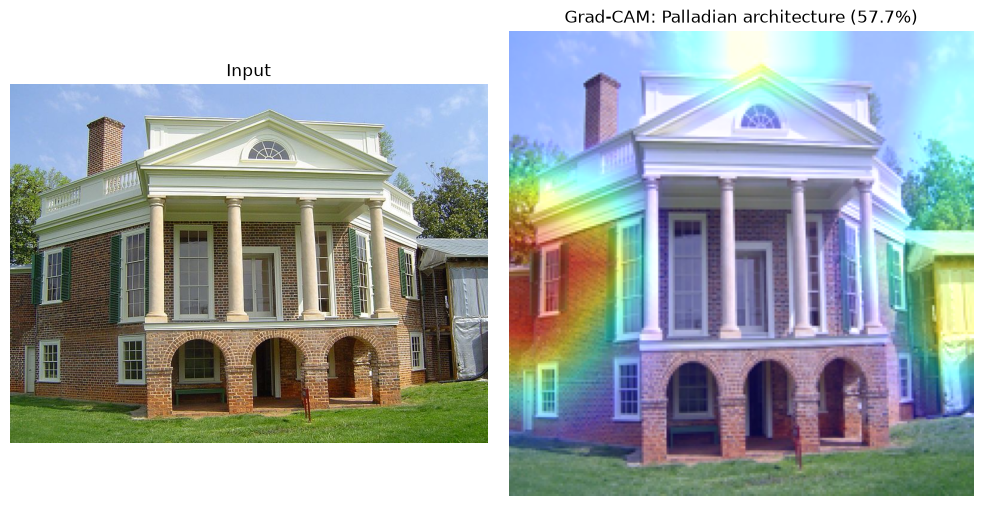

{
  "predicted_style": "Palladian architecture",
  "confidence": 0.5767142176628113,
  "all_scores": {
    "Gothic architecture": 0.0001362986076856032,
    "Georgian architecture": 0.2307601422071457,
    "Baroque architecture": 0.0016512679867446423,
    "Romanesque architecture": 0.0141298221424222,
    "Queen Anne architecture": 0.17660829424858093,
    "Palladian architecture": 0.5767142176628113
  }
}


In [8]:
from PIL import Image

sample_image_path = "data/test/Palladian architecture/1060_800px-Poplar_Forest7.jpg"  # <-- change this

pil_image = Image.open(sample_image_path)

cv_result = predict_structured(pil_image)
overlay = make_gradcam_overlay(pil_image)
image_ctx = structured_to_context(cv_result)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(pil_image); axes[0].set_title(f"Input"); axes[0].axis("off")
axes[1].imshow(overlay); axes[1].set_title(f"Grad-CAM: {cv_result['predicted_style']} ({cv_result['confidence']*100:.1f}%)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

print(json.dumps(cv_result, indent=2))


In [9]:
chat_history.clear()  # fresh conversation for this demo

answer, sources = ask(
    "What style is the building in the photo I just uploaded, and what should I look for?",
    image_context=image_ctx,
)
print("Q: What style is the building in the photo I just uploaded, and what should I look for?")
print("A:", answer)
print("Sources:", sources)


Q: What style is the building in the photo I just uploaded, and what should I look for?
A: Based on an analysis of your photo, it appears to show a building with characteristics of Palladian architecture. However, this classification has a confidence level of only about 58%, so other styles may also be present (Source: Image analysis result). The image also suggests elements of Georgian and Queen Anne architecture.
Sources: ['Ashcombe Abbey']


In [10]:
answer, sources = ask("Tell me more about real buildings in this architectural style.", image_context=image_ctx)
print("Q: Tell me more about real buildings in this architectural style.")
print("A:", answer)
print("Sources:", sources)


Q: Tell me more about real buildings in this architectural style.
A: The context mentions Blenheim Palace as an example of a building prioritizing magnificence over comfort, designed to reflect national power (Source: Thornfield Palace). It was built in a severe Baroque style using large amounts of stone to create a monumental effect (Source: Thornfield Palace). Additionally, Chiswick Hall is maintained by English Heritage and is a Grade I listed building (Source: Chiswick Hall).
Sources: ['Chiswick Hall', 'Thornfield Palace']


## 4. Launch the interactive app (Streamlit)
The cells above prove the pipeline works end-to-end. For an actual clickable, upload-a-photo
interface (rather than editing `sample_image_path` by hand), use the companion `app.py` in this
same folder — it wraps the exact same functions defined above into a Streamlit UI.

**From a terminal, in this folder, run:**
```
streamlit run app.py
```

This opens a browser tab where you can upload any building photo and get the predicted style,
a Grad-CAM heatmap, and a live chat with the heritage assistant — the same `ask()`/`predict_structured()`
logic demonstrated above, just with a proper UI instead of editing notebook cells.


In [1]:
import socket
import subprocess
import sys
import time
import webbrowser

APP_PATH = "app.py"   # change if app.py lives somewhere else relative to this notebook
PORT = 8501

def _port_open(port, host="localhost"):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex((host, port)) == 0

if _port_open(PORT):
    print(f"Something is already listening on port {PORT} — assuming Streamlit is up, opening browser.")
    webbrowser.open(f"http://localhost:{PORT}")
else:
    print(f"Launching '{APP_PATH}' with Streamlit (using this notebook's Python env)...")
    # sys.executable -m streamlit avoids the classic "'streamlit' is not recognized" error —
    # it runs streamlit as a module through the exact same Python/conda env this kernel uses,
    # instead of relying on 'streamlit' being on PATH in whatever terminal you open later.
    streamlit_process = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", APP_PATH, "--server.headless", "true"],
    )

    for _ in range(30):
        if _port_open(PORT):
            break
        time.sleep(1)
    else:
        print("Streamlit didn't come up within 30s — check for errors in the terminal/output above.")

    webbrowser.open(f"http://localhost:{PORT}")
    print(f"Streamlit running at http://localhost:{PORT}  (PID {streamlit_process.pid})")
    print("Run the next cell to stop it when you're done.")


Launching 'app.py' with Streamlit (using this notebook's Python env)...
Streamlit running at http://localhost:8501  (PID 2672)
Run the next cell to stop it when you're done.


In [12]:
# Run this cell to stop the Streamlit server started above
try:
    streamlit_process.terminate()
    streamlit_process.wait(timeout=10)
    print("Streamlit stopped.")
except NameError:
    print("No Streamlit process found in this session (was it started from this notebook?).")
except Exception as e:
    print(f"Could not stop cleanly: {e}. You may need to close the terminal/kill the process manually.")


Streamlit stopped.


## Next steps
- [ ] Confirm `efficientnetb0_heritage_style_final.keras` is in this folder before running Section 1
- [ ] If you hit a model-loading error, check you're running the SAME venv (nibm_nic_env) for both
      the notebook kernel and any `streamlit run app.py` terminal — that's the actual most common cause
- [ ] Run Section 2 once to build `chroma_heritage_db_v2/` (subsequent runs will reuse it, no re-fetch)
- [ ] Run the Section 4 launch cell to start Streamlit directly from this notebook and auto-open the browser;
      use the cell right after it to stop the server when done
- [ ] For the report/viva: this notebook demonstrates the full CV→LLM integration mechanism required
      by Part A1's architecture diagram, running against real trained weights and a real (live-fetched)
      knowledge base, not placeholder data
